# Flow matching for generative modeling

The notebook implements generative modeling with an ordinary differential equation (ODE)
for a latent variable $x_t$, $t\in [0,1]$:
\begin{align*}
x_0 & \sim p_0(x_0)\\ dx & = v(x,t) dt \\ y & = x_1 
\end{align*}
with the prior being a standard Gaussian: $p_0(x_0)=\mathcal{N}(x_0|0,1)$.

We simulate data from a known one-dimensional distribution and learn the drift $v(x,t)$,
parameterized as a neural network, by using [flow matching](https://arxiv.org/abs/2210.02747).

Flow matching learns a *flow* (velocity field) $v(x,t)$. It is a special case of the variational SDE framework from the SDE notebook, obtained by
fixing the conditional path to a **stochastic interpolant**
$$
x_t = t\,y + \beta_t\,\varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,1),
\qquad \beta_t = (1-t)\beta_0 + t\beta_1
$$
corresponding to a variational distribution
$q_t(x|y) = \mathcal{N}(x \mid \alpha(y,t),\, \beta^2(y,t))$ with $\alpha(y,t) = t y$ and $\beta(y,t)= \beta_t = (1-t)\beta_0 + t\beta_1$.

The flow matching objective is given by
$$
\mathcal{L}_{\mathrm{FM}}
=  \mathbb{E}_{t\sim U([0,1]),\varepsilon\sim \mathcal{N}(0,I)}\!\left[\frac{\|v(x_t,t) - g_{\mathrm{flow}}(x_t,y,t)\|^2}{\sigma^2(x_t,t)}\right]
$$
with variational flow given by 
$$
g_{\mathrm{flow}}(x,y,t) = \frac{\partial \alpha(y,t)}{\partial t} + \frac{\partial \beta(y,t)}{\partial t} \frac{x-\alpha(y,t)}{\beta(y,t)}  = y + (\beta_1-\beta_0)   \frac{x-ty}{(1-t)\beta_0 + t\beta_1} \ .
$$
With $\sigma=1$ this is a plain MSE — no autograd over $t$ required, unlike the SDE notebook.
 
**Full ELBO.** To have a well-defined ELBO, we need to use a Gaussian likelihood with a (small) width $\delta$. The prior and reconstruction terms have closed forms:
$$
-\mathrm{KL}(q_0\|p_0) = \tfrac{1}{2}(\log\beta_0^2 + 1 - \beta_0^2), \qquad
\mathbb{E}_{q_1}[\log p(y|x_1)] = -\tfrac{1}{2}\!\left(\frac{\beta_1^2}{\delta^2}+\log 2\pi\delta^2\right) \ .
$$
The ELBO diffusion term is two time $\mathcal{L}_{\mathrm{FM}}$. 
For the default $(\beta_0,\beta_1)=(1,0)$ both are constants (no model parameters), and the ELBO
reduces to $-\mathcal{L}_{\mathrm{FM}}$ plus a constant. Optimising $\delta, \beta_0,\beta_1$ and/or
$\sigma(x,t)$ can improve the bound.

**Generation.** The learned $v(x,t)$ defines a generative ODE $dx = v(x,t)\,dt$ starting from
$x_0\sim\mathcal{N}(0,1)$ that can be integrated with either Euler or Runge-Kutta.

## Setup

In [1]:
import os, sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    os.system("wget -q https://raw.githubusercontent.com/olewinther/generative-ode-sde/main/utils.py")
else:
    for path in ['..', '.']:
        if os.path.exists(os.path.join(path, 'utils.py')):
            sys.path.insert(0, os.path.abspath(path))
            break

from utils import *

## GPU

In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('GPU State:', device)

GPU State: cpu


## Interpolant parameters

In [3]:
import torch.nn as nn

class InterpolantParams(nn.Module):
    """
    Stochastic interpolant parameters beta_0 and beta_1.
    Set trainable=True to jointly optimise them with the flow network.
    Parameterised as log(beta) to ensure positivity.
    """
    def __init__(self, beta_0=1.0, beta_1=1e-3, trainable=False):
        super().__init__()
        for name, val in [('log_beta_0', beta_0), ('log_beta_1', beta_1)]:
            buf = torch.log(torch.tensor(float(val)))
            if trainable:
                setattr(self, name, nn.Parameter(buf))
            else:
                self.register_buffer(name, buf)

    def beta_0(self):
        return torch.exp(self.log_beta_0)

    def beta_1(self):
        return torch.exp(self.log_beta_1)

    def beta_t(self, t):
        return (1 - t) * self.beta_0() + t * self.beta_1()

## Flow and diffusion networks

In [4]:
class FlowNetwork(nn.Module):
    """Learns the flow v(x,t): the ODE drift in flow matching."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=-1))


class DiffusionNetwork(nn.Module):
    """
    Optional: learns sigma(x,t).
    Used for sigma-weighted training objective and for SDE generation.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x, t):
        return nn.Softplus()(self.net(torch.cat([x, t], dim=-1)))

In [5]:
def plot_v_alpha_beta(v_net, interp, num_samples=3):
    t_grid = torch.linspace(0, 1, 100).unsqueeze(1)
    y_samples = torch.randn(num_samples, 1)
    x_samples = torch.randn(num_samples, 1)

    fig, axes = plt.subplots(3, 1, figsize=(10, 9))

    ax = axes[0]
    for s in x_samples:
        with torch.no_grad():
            vals = [v_net(s, t.expand_as(s)).item() for t in t_grid]
        ax.plot(t_grid.numpy(), vals, label=f"x={s.item():.2f}")
    ax.set_title("v(x,t)"); ax.set_xlabel("t"); ax.set_ylabel("v(x,t)"); ax.legend()

    ax = axes[1]
    for s in y_samples:
        vals = [t.item() * s.item() for t in t_grid]
        ax.plot(t_grid.numpy(), vals, label=f"y={s.item():.2f}")
    ax.set_title(r"$\alpha(y,t) = t \cdot y$"); ax.set_xlabel("t"); ax.set_ylabel(r"$\alpha(y,t)$"); ax.legend()

    ax = axes[2]
    with torch.no_grad():
        beta_vals = [interp.beta_t(t).item() for t in t_grid]
    ax.plot(t_grid.numpy(), beta_vals)
    ax.set_title(r"$\beta(t)$"); ax.set_xlabel("t"); ax.set_ylabel(r"$\beta(t)$")

    plt.tight_layout(); plt.show()

## Training functions

In [ ]:
def sample_interpolant(y, t, params):
    """Sample x_t ~ q(x_t|y) = N(x_t | t*y, beta_t^2)."""
    eps = torch.randn_like(y)
    x_t = t * y + params.beta_t(t) * eps
    return x_t, eps


def compute_target_drift(y, eps, params):
    """
    Closed-form conditional drift:
      g(x_t, y, t) = d(alpha)/dt + (d(beta_t)/dt / beta_t) * (x_t - alpha)
                   = y + (beta_1 - beta_0) * eps
    For standard (beta_0=1, beta_1~0): g ≈ y - eps, constant in t.
    """
    return y + (params.beta_1() - params.beta_0()) * eps


def compute_flow_matching_loss(v_net, y, t_sample, params, sigma_net=None):
    """
    Flow matching objective: E[ ||v(x_t,t) - g(x_t,y,t)||^2 / sigma^2(x_t,t) ].
    sigma_net=None uses sigma=1 (standard, unweighted MSE).
    The factor-of-2 from the SDE parameterisation (f_flow = 2v - backward_g) is
    omitted here and absorbed into the ELBO monitoring below.
    """
    x_t, eps = sample_interpolant(y, t_sample, params)
    g = compute_target_drift(y, eps, params)
    v = v_net(x_t, t_sample)
    sq_err = (v - g) ** 2
    if sigma_net is not None:
        sq_err = sq_err / sigma_net(x_t, t_sample) ** 2
    return sq_err.mean()


def compute_elbo_fm(v_net, y, t_sample, params, delta=1e-2, sigma_net=None):
    """
    Full ELBO for monitoring (signs match the SDE notebook convention):
      ELBO = likelihood_term - kl_term - drift_term
    All three terms are shown separately to connect with the theory.

    Note: likelihood_term and kl_term are constants when beta_0, beta_1 are fixed.
          They become tunable when InterpolantParams(trainable=True).
    """
    beta_0 = params.beta_0()
    beta_1 = params.beta_1()

    # E[log p(y|x_1)] for Gaussian likelihood N(y | x_1, delta^2)
    # x_1 = y + beta_1*eps => E[(y-x_1)^2] = beta_1^2
    likelihood_term = -0.5 * (beta_1 ** 2 / delta ** 2 + torch.log(2 * torch.pi * torch.tensor(delta ** 2)))

    # KL(q_0 || N(0,I)) = KL(N(0, beta_0^2) || N(0,1)) = 0.5*(beta_0^2 - 1 - log beta_0^2)
    kl_term = 0.5 * (beta_0 ** 2 - 1 - 2 * torch.log(beta_0))

    # Drift matching term (factor 2 from SDE parameterisation: f_flow = 2v - backward_g)
    drift_term = 2 * compute_flow_matching_loss(v_net, y, t_sample, params, sigma_net)

    elbo = likelihood_term - kl_term - drift_term
    return elbo, likelihood_term, kl_term, drift_term


def make_prior_fm(params):
    """Return a Prior matching the interpolant at t=0: N(0, beta_0^2)."""
    def sample(n):
        b0 = params.beta_0().item()
        return torch.tensor(np.random.normal(0, b0, size=(n, 1)), dtype=torch.float32)
    def log_prob(x):
        b0 = params.beta_0()
        return -0.5 * (x / b0) ** 2 - 0.5 * torch.log(2 * torch.pi * b0 ** 2)
    return Prior(sample, log_prob)


def training_loop_fm(v_net, params, data_loader, validation_data,
                     sigma_net=None, delta=1e-2, n_epochs=1000, lr=1e-3):
    from collections import deque
    trainable = list(v_net.parameters()) + list(params.parameters())
    if sigma_net is not None:
        trainable += list(sigma_net.parameters())
    optimizer = torch.optim.Adam(trainable, lr=lr)
    train_history, val_history = deque(maxlen=5), deque(maxlen=5)

    for epoch in range(n_epochs):
        total_loss = 0.0
        for y_batch in data_loader:
            optimizer.zero_grad()
            t_sample = torch.rand(y_batch.size())
            loss = compute_flow_matching_loss(v_net, y_batch, t_sample, params, sigma_net)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()

        if epoch % 50 == 0 or epoch == n_epochs - 1:
            t_val = torch.rand(validation_data.size())
            elbo_val, ll, kl, dm = compute_elbo_fm(
                v_net, validation_data, t_val, params, delta=delta, sigma_net=sigma_net)
            b0, b1 = params.beta_0().item(), params.beta_1().item()
            train_cur = total_loss / len(data_loader)
            val_cur = elbo_val.item()
            train_history.append(train_cur)
            val_history.append(val_cur)
            avg_train = sum(train_history) / len(train_history)
            avg_val = sum(val_history) / len(val_history)
            print(f"Epoch {epoch:4d} | train {train_cur:.4f} (avg {avg_train:.4f}) | "
                  f"ELBO {val_cur:.4f} (avg {avg_val:.4f}) | "
                  f"ll={ll:.4f}, kl={kl:.4f}, drift={dm:.4f} | "
                  f"beta_0={b0:.4f} beta_1={b1:.4f}")

    return v_net, params, sigma_net

## Create training and validation data

In [7]:
torch.manual_seed(42)
np.random.seed(42)

n_samples, n_val = 1000, 8000

# Choose distribution: 'gaussian', 'laplace', 'laplace_mixture'
training_set_dist = 'laplace_mixture'

if training_set_dist == 'gaussian':
    params_dist = {'mean': torch.tensor(-1.0), 'std': torch.tensor(2.0)}
elif training_set_dist == 'laplace':
    params_dist = {'loc': torch.tensor(0.0), 'scale': torch.tensor(1.0)}
elif training_set_dist == 'laplace_mixture':
    params_dist = {'k': 5, 'spacing': 4.0, 'scale': torch.tensor(1.0)}

training_set = TrainingSetWithLogLikelihood(training_set_dist, params_dist)
training_data, ell_train = training_set.generate_training_data(n_samples)
validation_data, ell_val = training_set.generate_training_data(n_val)
print(f"{training_set_dist} | true log-likelihood: train={ell_train:.4f}, val={ell_val:.4f}")

laplace_mixture | true log-likelihood: train=-2.9829, val=-2.9862


## ODE generation: train and visualise

Before training:


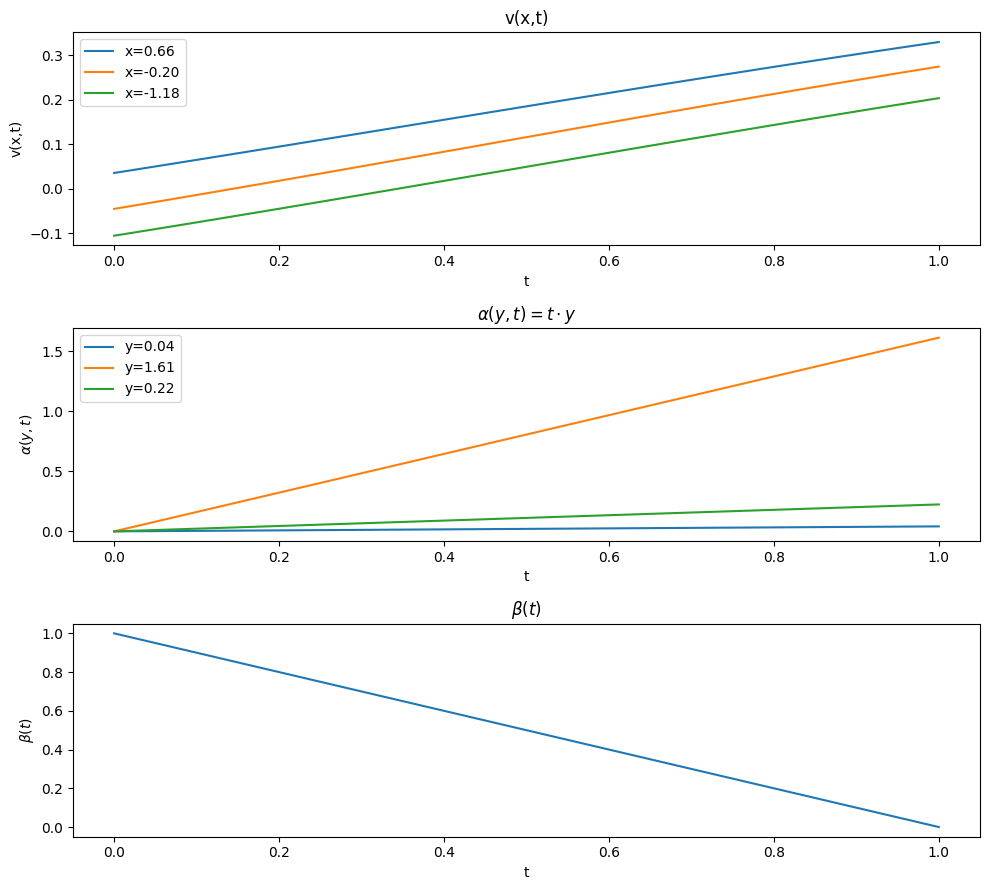

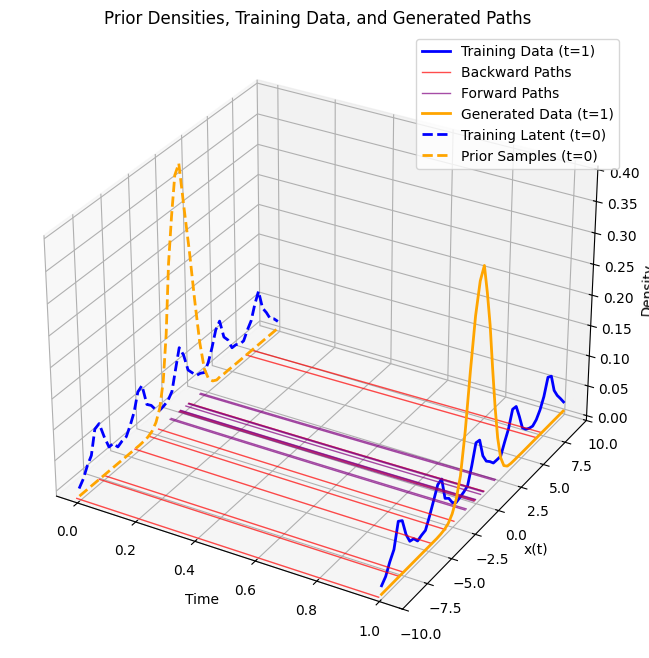

Epoch    0 | train 31.5925 | ELBO -44.7296 (ll=3.6862, kl=0.0000, drift=48.4158) | beta_0=1.0000 beta_1=0.0000
Epoch   50 | train 10.6425 | ELBO -16.5955 (ll=3.6862, kl=0.0000, drift=20.2818) | beta_0=1.0000 beta_1=0.0000
Epoch  100 | train 11.4138 | ELBO -16.7125 (ll=3.6862, kl=0.0000, drift=20.3987) | beta_0=1.0000 beta_1=0.0000
Epoch  150 | train 9.6187 | ELBO -14.5016 (ll=3.6862, kl=0.0000, drift=18.1879) | beta_0=1.0000 beta_1=0.0000
Epoch  200 | train 9.1504 | ELBO -14.8772 (ll=3.6862, kl=0.0000, drift=18.5635) | beta_0=1.0000 beta_1=0.0000
Epoch  250 | train 9.6084 | ELBO -15.0189 (ll=3.6862, kl=0.0000, drift=18.7051) | beta_0=1.0000 beta_1=0.0000
Epoch  300 | train 9.9723 | ELBO -14.3296 (ll=3.6862, kl=0.0000, drift=18.0159) | beta_0=1.0000 beta_1=0.0000
Epoch  350 | train 10.0656 | ELBO -14.7926 (ll=3.6862, kl=0.0000, drift=18.4788) | beta_0=1.0000 beta_1=0.0000
Epoch  400 | train 8.5619 | ELBO -14.0074 (ll=3.6862, kl=0.0000, drift=17.6937) | beta_0=1.0000 beta_1=0.0000
Epoch 

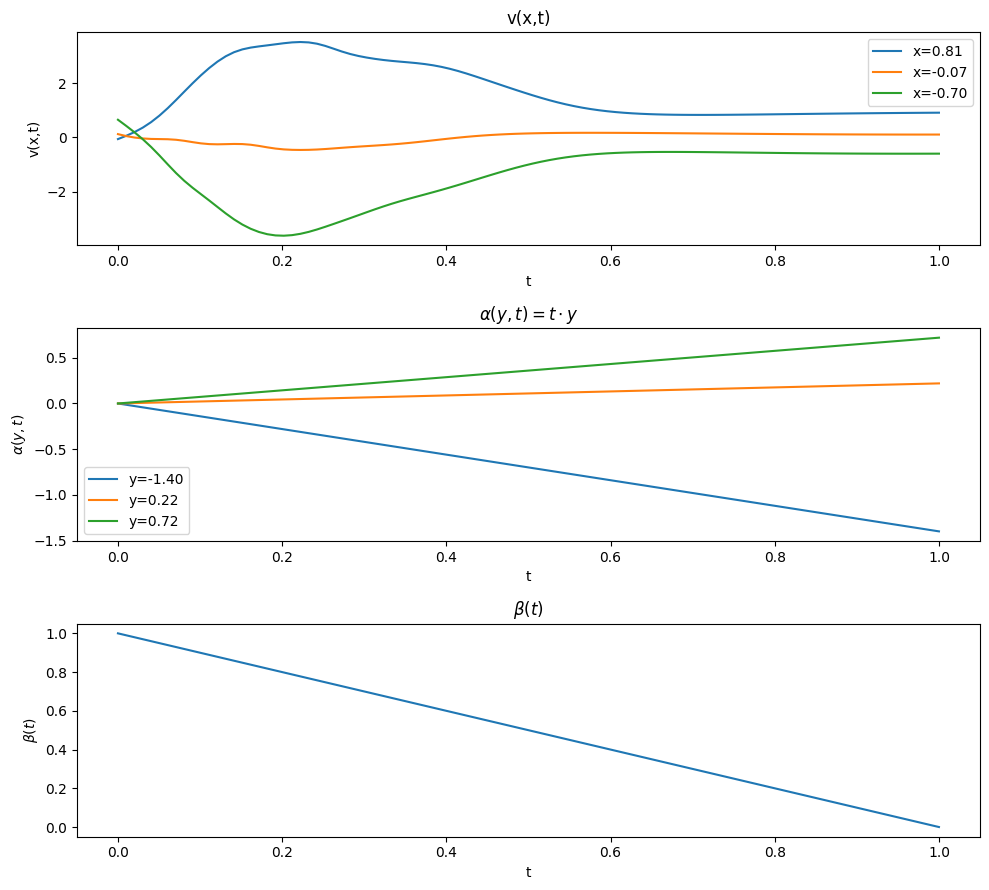

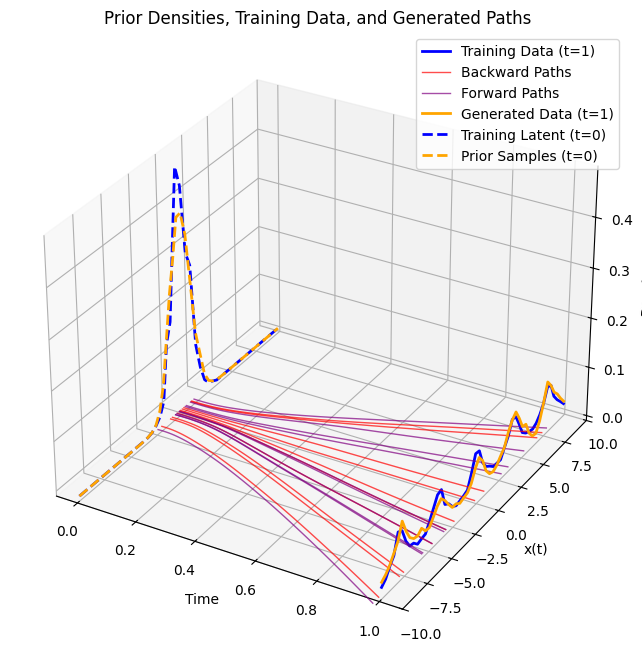

In [8]:
data_loader = torch.utils.data.DataLoader(training_data, batch_size=125, shuffle=True)

# --- Interpolant parameters ---
# trainable=False: standard flow matching with fixed beta_0=1, beta_1~0
# trainable=True:  jointly optimise beta_0 and beta_1 with the flow
interp = InterpolantParams(beta_0=1.0, beta_1=0.0, trainable=False)

# --- Flow network ---
v_net = FlowNetwork()

# --- Optional diffusion network (set to DiffusionNetwork() for sigma-weighted training) ---
sigma_net = None  # or DiffusionNetwork()

# --- Likelihood noise (only affects ELBO monitoring, not training) ---
delta = 1e-2

t = torch.linspace(0, 1, steps=100)
prior = make_prior_fm(interp)
forward_path  = ForwardPath(mode="ode", f_net=v_net, prior=prior)
backward_path = BackwardPath(mode="ode", f_net=v_net)

print("Before training:")
plot_v_alpha_beta(v_net, interp)
visualize_paths_and_marginals(validation_data, t, backward_path, forward_path)

v_net, interp, sigma_net = training_loop_fm(
    v_net, interp, data_loader, validation_data,
    sigma_net=sigma_net, delta=delta, n_epochs=10000, lr=1e-3,
)

# Update prior in case beta_0 changed (relevant when trainable=True)
prior = make_prior_fm(interp)
forward_path  = ForwardPath(mode="ode", f_net=v_net, prior=prior)
backward_path = BackwardPath(mode="ode", f_net=v_net)

print("After training:")
plot_v_alpha_beta(v_net, interp)
visualize_paths_and_marginals(validation_data, t, backward_path, forward_path)

## SDE generation (optional)

In [9]:
# ── SDE generation ──────────────────────────────────────────────────────────
# The learned v(x,t) also supports SDE generation via
#   dx = [2v(x,t) - backward_g(x,t)] dt + sigma(x,t) dW
# where backward_g is the reverse-time drift of the marginal q_t(x).
#
# For the stochastic interpolant, backward_g can be expressed through the
# variational Variational class from utils using the fixed alpha/beta:

class FixedAlpha(nn.Module):
    """alpha(y,t) = t*y  (fixed interpolant mean)."""
    def forward(self, y, t): return t * y

class FixedBeta(nn.Module):
    """beta(y,t) = beta_t  (fixed interpolant std)."""
    def __init__(self, interp): super().__init__(); self.interp = interp
    def forward(self, y, t): return self.interp.beta_t(t).expand_as(y)

# Generative SDE drift: f_sde(x,t) = 2*v(x,t) - backward_g(x,t)
class SDEFlowDrift(nn.Module):
    def __init__(self, v_net, interp, sigma_net_sde):
        super().__init__()
        self.v_net = v_net
        self.alpha_net = FixedAlpha()
        self.beta_net  = FixedBeta(interp)
        self.sigma_net = sigma_net_sde

    def forward(self, x, t):
        t = t.clone().requires_grad_(True)
        q = Variational(self.alpha_net, self.beta_net, x, t)  # use x as proxy for y (marginal)
        backward_g, _ = q.drift(x, mode="backward sde", sigma_net=self.sigma_net)
        return 2 * self.v_net(x, t) - backward_g.detach()

# To use: provide a trained sigma_net (DiffusionNetwork) and set sigma_net_sde below.
# sigma_net_sde = DiffusionNetwork()  # train jointly or separately
# sde_drift = SDEFlowDrift(v_net, interp, sigma_net_sde)
# forward_path_sde = ForwardPath(mode="sde", f_net=sde_drift, sigma_net=sigma_net_sde, prior=prior)
# visualize_paths_and_marginals(validation_data, t, backward_path, forward_path_sde)